Doing the analysis splitting impos and import + multiple linear regressions

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("CleanFlipAggData.csv")
df.head()

,HS,FM,GM,diff_import,diff_imposs,country
0,6.000000,2.5,4.0,2.0,2.5,Germany
1,3.666667,3.0,4.5,4.5,2.0,Germany
2,4.000000,4.5,5.5,4.5,4.0,Germany
3,2.333333,3.0,4.0,5.0,2.0,Germany
4,3.333333,1.0,5.5,2.5,4.5,Germany


In [5]:
len(df)

853

In [7]:
df["country"].value_counts()

country
USA             150
South Africa    149
Mexico          141
Spain           137
UK              120
Germany         104
Scandinavia      52
Name: count, dtype: int64

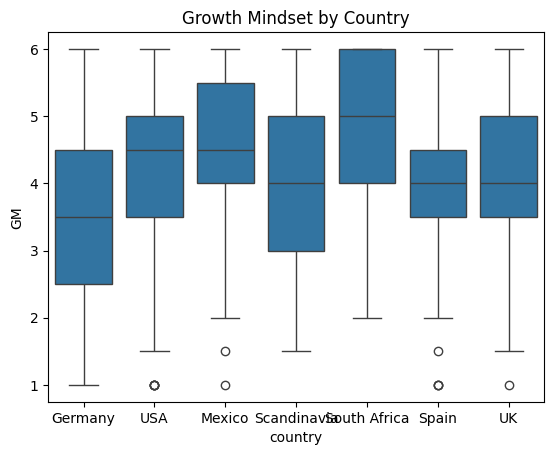

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(data=df, x="country", y="GM")
plt.title("Growth Mindset by Country")
plt.show()

bit of an issue with the names here...

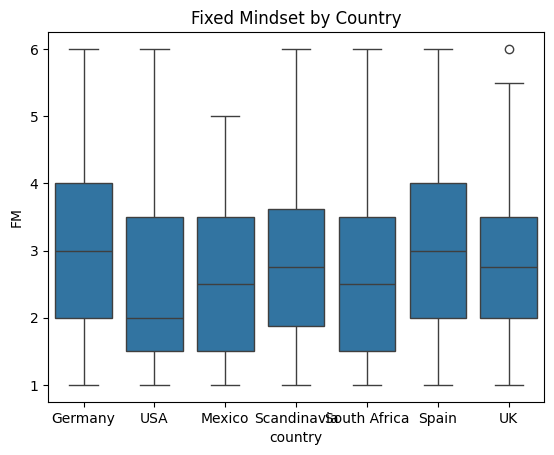

In [11]:
plt.figure()
sns.boxplot(data=df, x="country", y="FM")
plt.title("Fixed Mindset by Country")
plt.show()

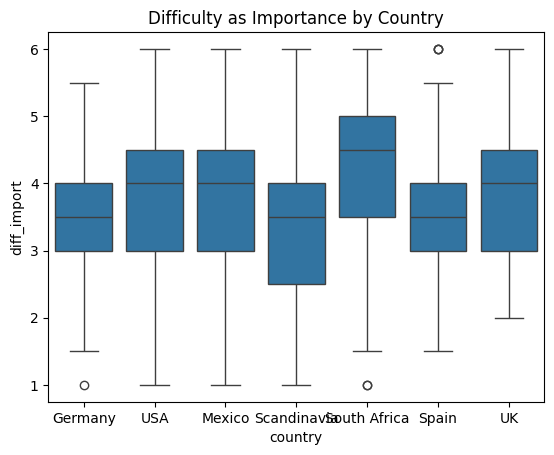

In [12]:
plt.figure()
sns.boxplot(data=df, x="country", y="diff_import")
plt.title("Difficulty as Importance by Country")
plt.show()

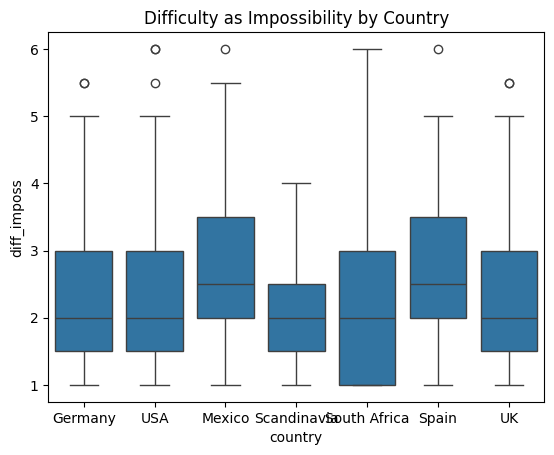

In [13]:
plt.figure()
sns.boxplot(data=df, x="country", y="diff_imposs")
plt.title("Difficulty as Impossibility by Country")
plt.show()

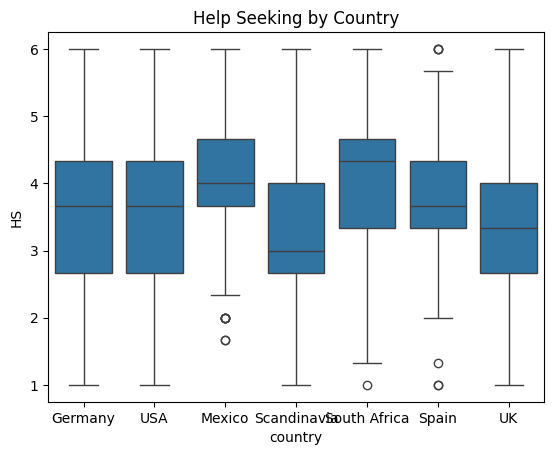

In [14]:
plt.figure()
sns.boxplot(data=df, x="country", y="HS")
plt.title("Help Seeking by Country")
plt.show()

We probably need to do something to handle outliers here, perhaps? 

Also figuring out a cleaner way to present all of this: 

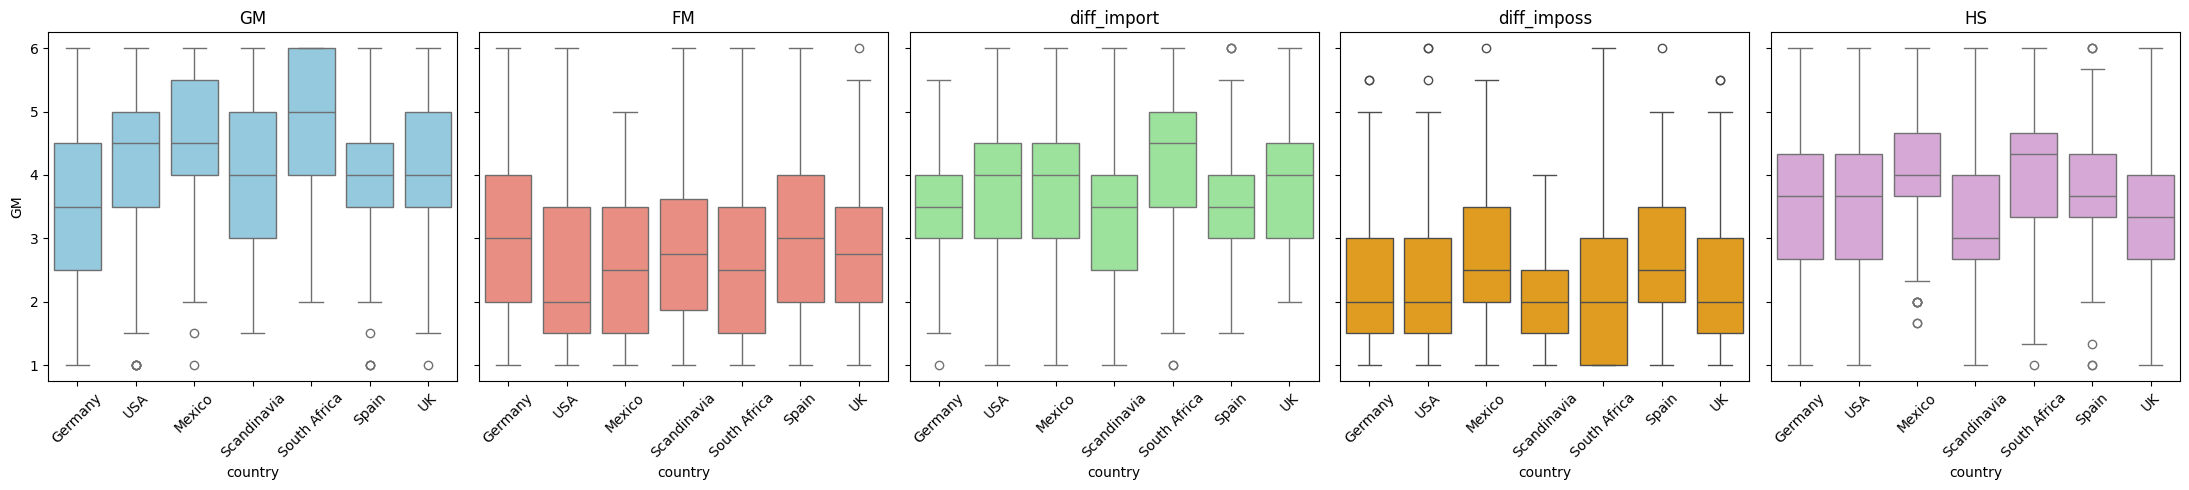

In [15]:
variables = [
    "GM",
    "FM",
    "diff_import",
    "diff_imposs",
    "HS"
]

colors = ["skyblue", "salmon", "lightgreen", "orange", "plum"]

fig, axes = plt.subplots(1, len(variables), figsize=(22, 5), sharey=True)

for i, var in enumerate(variables):
    sns.boxplot(
        data=df,
        x="country",
        y=var,
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Now moving on to some basic anova analysis

In [16]:
import scipy.stats as stats

variables = [
    "GM",
    "FM",
    "diff_import",
    "diff_imposs",
    "HS"
]

for var in variables:
    groups = [group[var].dropna() for name, group in df.groupby("country")]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"\n{var}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.6f}")


GM
F-statistic: 16.7492
p-value: 0.000000

FM
F-statistic: 2.3695
p-value: 0.028196

diff_import
F-statistic: 7.9845
p-value: 0.000000

diff_imposs
F-statistic: 2.4494
p-value: 0.023566

HS
F-statistic: 8.7025
p-value: 0.000000


Now doing regression 

In [81]:
import statsmodels.api as sm

for outcome in ["diff_import", "diff_imposs"]:
    y = df[outcome]
    print(f"\n{'='*60}\nOutcome: {outcome}\n{'='*60}")
    
    for predictor in ["GM", "FM", "HS"]:
        X = sm.add_constant(df[[predictor]])
        model = sm.OLS(y, X).fit(cov_type='HC3')
        coef = model.params[predictor]
        pval = model.pvalues[predictor]
        print(f"{predictor}: coef={coef:.3f}, p={pval:.3f}")


Outcome: diff_import
GM: coef=0.194, p=0.000
FM: coef=0.011, p=0.727
HS: coef=0.122, p=0.001

Outcome: diff_imposs
GM: coef=-0.083, p=0.013
FM: coef=0.284, p=0.000
HS: coef=-0.057, p=0.108


In [82]:
df = df.loc[:, ~df.columns.duplicated()].copy()
country_cols = [col for col in df.columns if col.startswith("country_")]

for outcome in ["diff_import", "diff_imposs"]:
    outcome_predictor = "GM" if outcome == "diff_import" else "FM"
    
    reg_vars = [outcome, outcome_predictor, "HS"] + country_cols
    reg_df = df[reg_vars].copy()
    
    for col in country_cols:
        reg_df[col] = reg_df[col].astype(int)
    for col in [outcome, outcome_predictor, "HS"]:
        reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")
    
    reg_df = reg_df.dropna()
    
    X = reg_df[[outcome_predictor, "HS"] + country_cols]
    X = sm.add_constant(X)
    y = reg_df[outcome]
    
    print(f"\n{'='*60}\nOutcome: {outcome} | Predictor: {outcome_predictor}\n{'='*60}")
    model = sm.OLS(y, X).fit(cov_type="HC3")
    print(model.summary())


Outcome: diff_import | Predictor: GM
                            OLS Regression Results                            
Dep. Variable:            diff_import   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     9.558
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.01e-12
Time:                        20:25:23   Log-Likelihood:                -1242.8
No. Observations:                 853   AIC:                             2504.
Df Residuals:                     844   BIC:                             2546.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

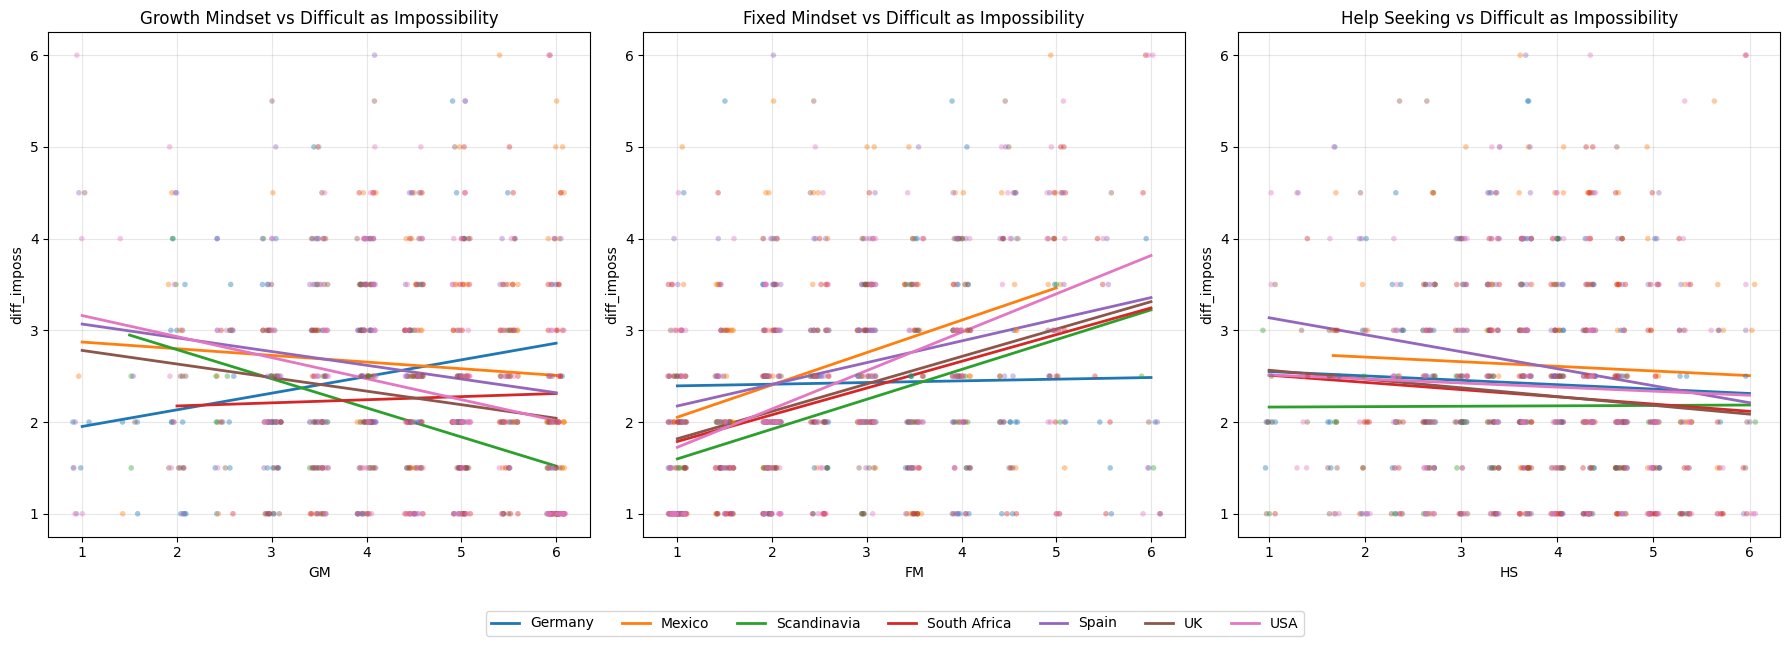

In [75]:
country_cols = [col for col in df.columns if col.startswith("country_")]
df["country"] = df[country_cols].idxmax(axis=1).str.replace("country_", "", regex=False)
germany_mask = df[country_cols].sum(axis=1) == 0
df.loc[germany_mask, "country"] = "Germany"
plot_df = df[["GM", "FM", "HS", "diff_import", "diff_imposs", "country"]].copy()
plot_df = plot_df.dropna()

palette = sns.color_palette("tab10", len(plot_df["country"].unique()))
country_colors = dict(zip(sorted(plot_df["country"].unique()), palette))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (col, title) in zip(axes, predictors):
    sns.stripplot(data=plot_df, x=col, y="diff_imposs", hue="country",
                  palette=country_colors, alpha=0.4, jitter=0.2, size=4,
                  ax=ax, legend=False, native_scale=True)

    for country, group in plot_df.groupby("country"):
        m, b = np.polyfit(group[col], group["diff_imposs"], 1)
        x_range = np.linspace(group[col].min(), group[col].max(), 100)
        ax.plot(x_range, m * x_range + b, label=country, linewidth=2, color=country_colors[country])

    ax.set_title(f"{title} vs Difficult as Impossibility")
    ax.set_xlabel(col)
    ax.set_ylabel("diff_imposs")
    ax.grid(True, alpha=0.3)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=8, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

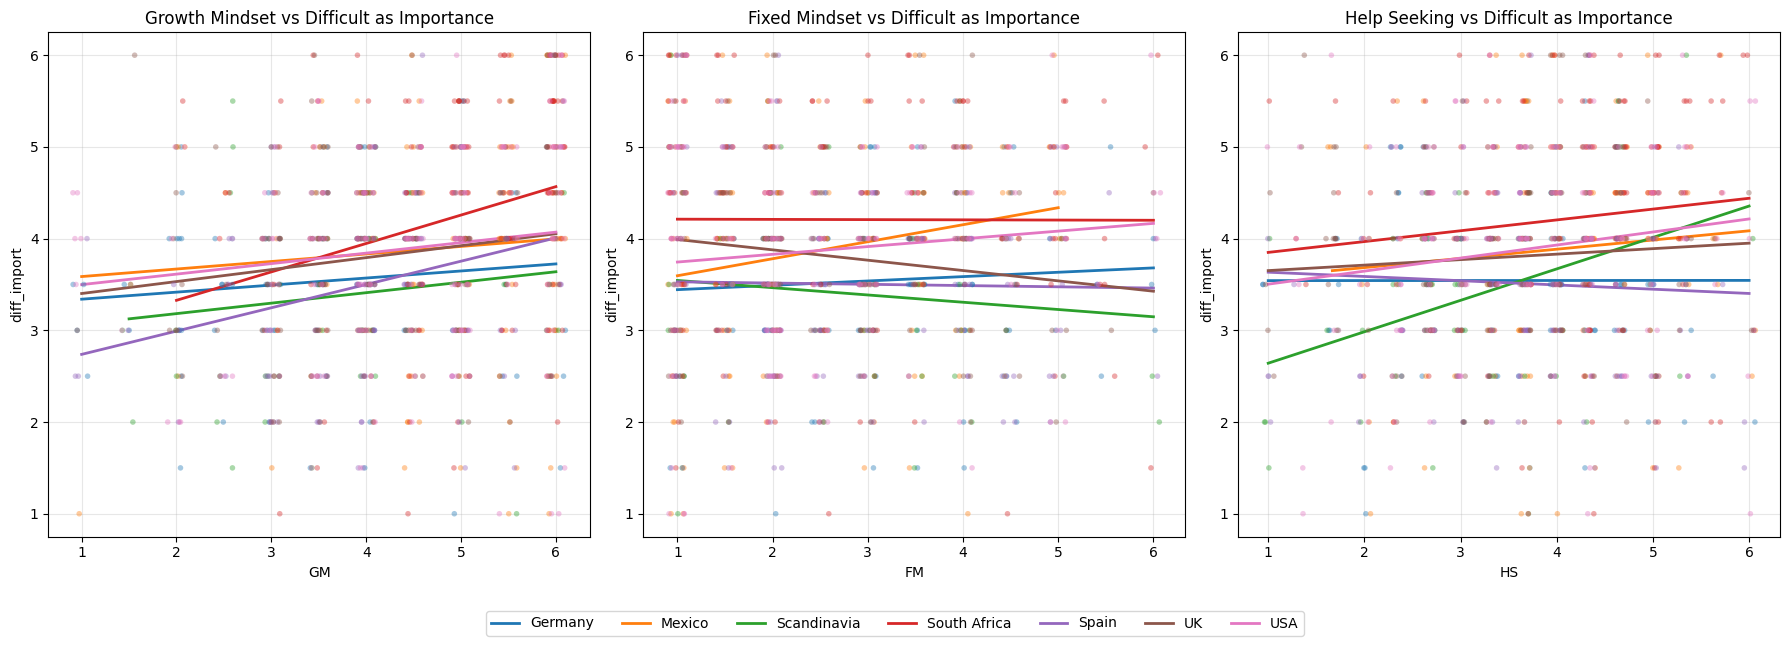

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
predictors = [("GM", "Growth Mindset"), ("FM", "Fixed Mindset"), ("HS", "Help Seeking")]
for ax, (col, title) in zip(axes, predictors):
    sns.stripplot(data=plot_df, x=col, y="diff_import", hue="country",
                  palette=country_colors, alpha=0.4, jitter=0.2, size=4,
                  ax=ax, legend=False, native_scale=True)

    for country, group in plot_df.groupby("country"):
        m, b = np.polyfit(group[col], group["diff_import"], 1)
        x_range = np.linspace(group[col].min(), group[col].max(), 100)
        ax.plot(x_range, m * x_range + b, label=country, linewidth=2, color=country_colors[country])

    ax.set_title(f"{title} vs Difficult as Importance")
    ax.set_xlabel(col)
    ax.set_ylabel("diff_import")
    ax.grid(True, alpha=0.3)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=8, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

In [84]:
model_imposs = smf.ols(
    formula="diff_imposs ~ FM * C(country) + HS * C(country)",
    data=plot_df
).fit(cov_type="HC3")
print(model_imposs.summary())

model_import = smf.ols(
    formula="diff_import ~ GM * C(country) + HS * C(country)",
    data=plot_df
).fit(cov_type="HC3")
print(model_import.summary())

                            OLS Regression Results                            
Dep. Variable:            diff_imposs   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     6.966
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           3.61e-18
Time:                        20:27:19   Log-Likelihood:                -1220.3
No. Observations:                 853   AIC:                             2483.
Df Residuals:                     832   BIC:                             2582.
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

Conclusions



Fixed mindset is the strongest predictor of seeing difficult tasks as impossible, and growth mindset predicts seeing difficult tasks as important — both consistent with theoretical expectations.

For difficult tasks as impossible, fixed mindset drives the effect across most countries, but interestingly Germany is the exception. FM has almost no relationship with impossibility framing for German students, while the effect is significant and meaningful in Mexico, Scandinavia, South Africa, the UK, and the USA. Help seeking shows no significant country-level interactions for this outcome.

For difficult tasks as important, the picture is less definitive. Growth mindset shows a modest positive effect overall, but this largely washes out once country is accounted for, suggesting GM's relationship with importance is a general tendency rather than something that varies meaningfully by country. The one standout finding is Scandinavia: students who seek help are more likely to see difficult tasks as important, which may reflect a cultural norm around collaborative engagement with challenge.

South Africa remains a notable country in the importance model. students there rate difficult tasks as more important even after accounting for mindset, suggesting a cultural disposition toward valuing challenge that operates independently of individual mindset beliefs.
